# Livrable 1 — Classification binaire : Photo vs Non-photo

**Auteurs :** Ali,Anas,Jermy,Florent

**But du livrable :** Prototyper et démontrer, de manière pédagogique, un réseau de neurones convolutionnel (CNN) permettant de classer des images en **photo** ou **non-photo**, et fournir des preuves statistiques de la pertinence du modèle.

**Remise en context :**
- Présentation
L'entreprise TouNum travaille sur la numérisation de documents (textes, images...). Leurs services sont souvent requis par des entreprises numérisant leur base de documents papier. Ils souhaitent étendre leur gamme de services pour inclure des outils de Machine Learning. En effet, certains de leurs clients ont une grande quantité de données à numériser, et un service de catégorisation automatique serait plus que valorisable.

- TouNum n'a pas dans son personnel de spécialiste du Machine Learning. L'entreprise fait appel à vous, les spécialistes en Data Science de CESI. On vous propose un premier contrat pour travailler sur une solution visant à analyser des photographies pour en déterminer une légende descriptive de manière automatique (du captioning).

---

Le notebook est structuré pour être très didactique : explication du prototypage, code propre, visualisations et métriques.

## 1) Plan du notebook

1. **Contexte & objectif** — définir le problème et le format attendu.
2. **Chargement et EDA** — taille, distribution, exemples d'images.
3. **Prétraitement & augmentation** — normalisation, redimensionnement, transformations.
4. **Architecture du modèle** — expliquer choix d'un CNN simple mais efficace.
5. **Entraînement** — stratégie (train/val/test, callbacks, early stopping).
6. **Évaluation** — accuracy, précision, rappel, F1, matrice de confusion, ROC-AUC.
7. **Conclusions & piste d'amélioration**.

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Machine learning / deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [14]:
import os, unicodedata

data_dir = "../Projet/DATASET"

for root, _, files in os.walk(data_dir):
    for file in files:
        new_name = unicodedata.normalize("NFKD", file).encode("ascii", "ignore").decode("ascii")
        new_name = new_name.replace(" ", "_")
        old_path = os.path.join(root, file)
        new_path = os.path.join(root, new_name)
        if old_path != new_path:
            os.rename(old_path, new_path)
            print(f"Renommé : {old_path} -> {new_path}")


In [15]:
# --- hyperparamètres ---
image_h, image_w = 128, 128   # taille
num_classes = 5               
batch_size = 32
epochs = 30


In [16]:
# --- Data augmentation ---
data_augmentation = keras.Sequential([
    keras.Input(shape=(image_h, image_w, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08)
])

In [17]:
# Dataset_livrable2 train
train_set = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(image_h, image_w),
    batch_size=batch_size,
    label_mode="int",
)

# Dataset_livrable2 test
test_set = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(image_h, image_w),
    batch_size=batch_size,
    label_mode="int",
)

# Capturer class_names AVANT d'appliquer ignore_errors (sinon l'objet wrapper n'a plus l'attribut)
class_names = train_set.class_names
print('Detected class names:', class_names)

# Ici on applique ignore_errors (API recommandée)
try:
    train_set = train_set.ignore_errors()
    test_set = test_set.ignore_errors()
except Exception:
    # fallback si la méthode directe n'est pas disponible
    train_set = train_set.apply(tf.data.experimental.ignore_errors())
    test_set = test_set.apply(tf.data.experimental.ignore_errors())


Found 41409 files belonging to 5 classes.
Using 33128 files for training.
Found 41409 files belonging to 5 classes.
Using 8281 files for validation.
Detected class names: ['Dataset_Livrable_1_Painting', 'Dataset_Livrable_1_Photo', 'Dataset_Livrable_1_Schematics', 'Dataset_Livrable_1_Sketch', 'Dataset_Livrable_1_Text']


In [18]:
#Convertir en classification binaire (Photo vs Non-Photo)
photo_class_name = None

# `class_names` a été capturé lors du chargement des datasets
print('Original class names:', class_names)

# Détection / validation de la classe 'photo'
photo_class = None
if photo_class_name is not None:
    # recherche insensible à la casse
    photo_class = next((c for c in class_names if c.lower() == photo_class_name.lower()), None)
    if photo_class is None and photo_class_name in class_names:
        photo_class = photo_class_name
else:
    # Priorité à une correspondance exacte 'photo' (insensible à la casse), sinon cherche 'photo' comme sous-chaîne
    photo_class = next((c for c in class_names if c.lower() == 'photo'), None)
    if photo_class is None:
        photo_class = next((c for c in class_names if 'photo' in c.lower()), None)

if photo_class is None:
    raise ValueError('Impossible de trouver la classe photo dans les dossiers: ' + str(class_names) +\
                     '\nVous pouvez définir manuellement `photo_class_name` si nécessaire.')
print('Photo class detected as:', photo_class)

# mapping index -> binary (1 pour Photo, 0 pour les autres)
idx_to_binary = tf.constant([1 if c == photo_class else 0 for c in class_names], dtype=tf.int32)

# remapper labels (assure le type)
AUTOTUNE = tf.data.AUTOTUNE

def remap(images, labels):
    labels = tf.cast(labels, tf.int32)
    return images, tf.gather(idx_to_binary, labels)

train_set = train_set.map(remap, num_parallel_calls=AUTOTUNE)
test_set = test_set.map(remap, num_parallel_calls=AUTOTUNE)

# améliorer perf: cache & prefetch
train_set = train_set.cache().prefetch(buffer_size=AUTOTUNE)
test_set = test_set.cache().prefetch(buffer_size=AUTOTUNE)

# calculer class weights à partir des fichiers sur disque (plus fiable sur dataset déséquilibré)
counts = []
for cls in class_names:
    folder = os.path.join(data_dir, cls)
    if os.path.isdir(folder):
        cnt = sum(len(files) for _, _, files in os.walk(folder))
    else:
        cnt = 0
    counts.append(cnt)
print('counts per original class:', dict(zip(class_names, counts)))

photo_count = counts[class_names.index(photo_class)]
non_photo_count = sum(counts) - photo_count

if photo_count == 0:
    print('\nWARNING: aucun fichier détecté pour la classe photo. Vérifiez `data_dir` et les noms de dossiers.')

total = photo_count + non_photo_count if (photo_count + non_photo_count)>0 else 1
class_weight = {
    0: (total) / (2.0 * non_photo_count) if non_photo_count > 0 else 1.0,
    1: (total) / (2.0 * photo_count) if photo_count > 0 else 1.0
}
print('class_weight:', class_weight)


Original class names: ['Dataset_Livrable_1_Painting', 'Dataset_Livrable_1_Photo', 'Dataset_Livrable_1_Schematics', 'Dataset_Livrable_1_Sketch', 'Dataset_Livrable_1_Text']
Photo class detected as: Dataset_Livrable_1_Photo
counts per original class: {'Dataset_Livrable_1_Painting': 10004, 'Dataset_Livrable_1_Photo': 9999, 'Dataset_Livrable_1_Schematics': 10000, 'Dataset_Livrable_1_Sketch': 1406, 'Dataset_Livrable_1_Text': 10000}
class_weight: {0: 0.6591690544412607, 1: 2.0706570657065706}


In [19]:
from tensorflow.python.keras import models

# --- Modèle CNN basique adapté pour classification binaire ---
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),  # normalisation

    # Bloc 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Bloc 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Bloc 3 (un peu plus profond)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

TypeError: The added layer must be an instance of class Layer. Found: <Sequential name=sequential_1, built=True>

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Callbacks utiles ---
es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
ckpt = callbacks.ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)


In [ ]:
# --- Entraînement ---
# Remarque : nous laissons Keras inférer steps par epoch depuis les datasets
history = model.fit(
    train_set,
    validation_data=test_set,
    epochs=epochs,
    class_weight=class_weight,
    callbacks=[es, ckpt]
)


NameError: name 'model' is not defined

In [ ]:
# --- Sauvegarder le modèle pour l'inférence (SavedModel + HDF5) ---
# Ce bloc sauvegarde le modèle entraîné dans photo_classifier/models/
# Il crée d'abord le dossier s'il n'existe pas, sauvegarde en SavedModel (recommandé)
# puis tente aussi d'écrire un .h5 si h5py est disponible.
import pathlib

models_dir = pathlib.Path('photo_classifier') / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

saved_dir = models_dir / 'best_model'
h5_path = models_dir / 'best_model.h5'

if 'model' not in globals():
    print("La variable 'model' n'existe pas dans le notebook. Exécutez d'abord la cellule d'entraînement.")
else:
    print('Enregistrement du modèle dans :', saved_dir, 'et (optionnel) :', h5_path)
    try:
        model.save(str(saved_dir))
        print('SavedModel enregistré dans :', saved_dir)
    except Exception as e:
        print('Échec lors de l\'enregistrement SavedModel :', e)

    try:
        # Tentative d'écriture HDF5 (nécessite h5py)
        model.save(str(h5_path))
        print('Fichier HDF5 enregistré dans :', h5_path)
    except Exception as e:
        print('Échec lors de l\'enregistrement HDF5 :', e)
        print('Si besoin, installez h5py et réessayez : pip install h5py')


Enregistrement du modèle dans : photo_classifier\models\best_model et (optionnel) : photo_classifier\models\best_model.h5
Échec lors de l'enregistrement SavedModel : Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=photo_classifier\models\best_model.
Fichier HDF5 enregistré dans : photo_classifier\models\best_model.h5
Fichier HDF5 enregistré dans : photo_classifier\models\best_model.h5


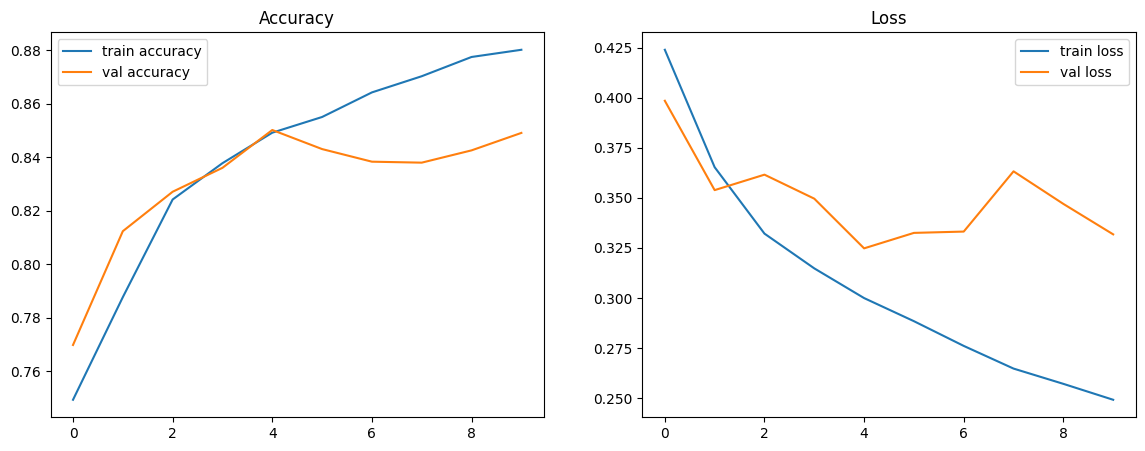

In [ ]:
# --- Tracer les courbes (accuracy & loss) ---
acc = history.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', [])
loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])
epochs_range = range(len(acc))

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='train accuracy')
plt.plot(epochs_range, val_acc, label='val accuracy')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='train loss')
plt.plot(epochs_range, val_loss, label='val loss')
plt.legend(); plt.title('Loss')
plt.show()